# Astrofisica: Classificazione dei corpi celesti

##### Importo librerie e lettura dati

In [1]:
# Importo librerie.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve
# train_test_split: divide i dati in training set e test set.
# KNeighborsClassifier: è il modello di Machine Learning k-NN già pronto.
# from sklearn.naive_bayes import GaussianNB: mi sernev per il modello beyesiano
# from sklearn.ensemble import RandomForestClassifier: è il modello del random forest
# accuracy_score, classification_report: funzioni per valutare la accuratezza del modello.

In [2]:
# Leggo i dati.
data=pd.read_csv("star_classification.csv") 

##### Data analysis e data cleaning per rendere migliori idati da usare

In [3]:
# Printo i primi 20 così capisco come sono fatti.
data.head(20)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [4]:
# Controllo i dati, vedo che ci sono NaN da togliere.
print(data.isnull().sum())
# Controllo come sono idati così se serve li cambio.
print(data.dtypes)

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object


In [5]:
# Trasformo la "classe" da un oggetto a una stringa così posso usarla.
data['class']=data['class'].astype('string')
# La printo per sicurezza.
print(data.dtypes)

obj_ID                float64
alpha                 float64
delta                 float64
u                     float64
g                     float64
r                     float64
i                     float64
z                     float64
run_ID                  int64
rerun_ID                int64
cam_col                 int64
field_ID                int64
spec_obj_ID           float64
class          string[python]
redshift              float64
plate                   int64
MJD                     int64
fiber_ID                int64
dtype: object


In [6]:
# Trasformo le stringhe "Galassia","Stella" e "Quasar" in numeri così posso usarli.
data['class']=data['class'].str.replace('GALAXY','0')
data['class']=data['class'].str.replace('STAR','1')
data['class']=data['class'].str.replace('QSO','2')
data.head(20)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,2,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,2,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,0,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,0,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,1,-0.000008,2444,54082,232


In [7]:
# Li trasformo in interi.
data['class']=data['class'].astype('int')
print(data.dtypes)

obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class            int64
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object


In [8]:
# Noto che a me servono solo le colonne della luminosità e della "classe". Quindi le altre le elimino.
data=data.drop('obj_ID',axis=1)
data=data.drop('alpha',axis=1)
data=data.drop('delta',axis=1)
data=data.drop('run_ID',axis=1)
data=data.drop('rerun_ID',axis=1)
data=data.drop('cam_col',axis=1)
data=data.drop('field_ID',axis=1)
data=data.drop('spec_obj_ID',axis=1)
data=data.drop('redshift',axis=1)
data=data.drop('plate',axis=1)
data=data.drop('MJD',axis=1)
data=data.drop('fiber_ID',axis=1)
data.head()
# A questo punto ho deti dati utili, quindi passo alla parte di machine learning.

,u,g,r,i,z,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,0
1,24.77759,22.83188,22.58444,21.16812,21.61427,0
2,25.26307,22.66389,20.60976,19.34857,18.94827,0
3,22.13682,23.77656,21.61162,20.50454,19.25010,0
4,19.43718,17.58028,16.49747,15.97711,15.54461,0


## Parte di Machine Learning

#### k-nn test (k-primi vicini)

##### Algoritmo ML per distinguere stelle, galassie e quasar (base, solo ugriz)

In [9]:
# Uso i colori in indice ugriz come features e la "class" come target.
fe=data[['u','g','r','i','z']]
ta=data['class']

In [10]:
# Per allenare l'algoritmo uso l'80% dei dati, il restante 20% lo uso per supervisionare.
fe_train,fe_test,ta_train,ta_test=train_test_split(fe,ta,test_size=0.2,random_state=26)
# Uso k=5 primi vicini.
model=KNeighborsClassifier(n_neighbors=5)
model.fit(fe_train,ta_train)
# Parte di predizione.
pred=model.predict(fe_test)
# Accuratezza.
print("Accuratezza:",accuracy_score(ta_test,pred))
# Risultato completo.
print("\nRisultato di classificazione:\n",classification_report(ta_test,pred))

Accuratezza: 0.8664

Risultato di classificazione:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92     11909
           1       0.80      0.75      0.77      4371
           2       0.81      0.77      0.79      3720

    accuracy                           0.87     20000
   macro avg       0.84      0.82      0.83     20000
weighted avg       0.86      0.87      0.86     20000



###### Noto che il modello va bene per le galassie (sarebbero la classe 0 del risultato), però fa fatica a predire le quasar e peggio ancora le stelle. 
###### Probabilmente è perchè le galassie sono di più. Provo a dargli come dati anche le differenze di indici così dovrebbe essere più semplice per l'algoritmo.

##### Algoritmo ML per distinguere stelle, galassie e quasar (parte 2, ugriz + differenze di indice, cioè colori)

In [11]:
# Creo le nuove colonne delle differenze di indici.
data['u-g']=data['u']-data['g']
data['g-r']=data['g']-data['r']
data['r-i']=data['r']-data['i']
data['i-z']=data['i']-data['z']

In [12]:
# Creo le nuove features (ugriz+differenze), il target è lo stesso.
feNuovo=data[['u','g','r','i','z','u-g','g-r','r-i','i-z']]
taNuovo=data['class']
# l'algoritmo "cuore" è uguale a quello di prima.
feNuovo_train,feNuovo_test,taNuovo_train,taNuovo_test=train_test_split(feNuovo,taNuovo,test_size=0.2,random_state=26)
# Uso k=5 primi vicini.
model=KNeighborsClassifier(n_neighbors=5)
model.fit(feNuovo_train,taNuovo_train)
# Parte di predizione.
predNuovo=model.predict(feNuovo_test)
# Accuratezza
print("Accuratezza:",accuracy_score(taNuovo_test,predNuovo))
# Risultato completo.
print("\nRisultato di classificazione:\n",classification_report(taNuovo_test,predNuovo))

Accuratezza: 0.8693

Risultato di classificazione:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92     11909
           1       0.80      0.76      0.78      4371
           2       0.82      0.77      0.79      3720

    accuracy                           0.87     20000
   macro avg       0.84      0.82      0.83     20000
weighted avg       0.87      0.87      0.87     20000



###### Con l'aggiunta delle differenze di indici nelle stelle e nelle quasar va un pochino meglio, però non cambia molto.

##### Per migliorare l'algoritmo provo a modificare il numero di primi vicini: 3, 5, 7, 9 e 11 e vedo come cambia.

In [ ]:
# Provo l'algoritmo usando 3, 5, 7, 9 e 11 vicini e confronto le due accuratezze.
# Features e target restano gli stessi (feNuovo e taNuovo).
x=[1,3,5,7,9,11,13,15,17,19,21,100]
y=[0]*len(x)
j=0
for i in x:
    # l'algoritmo "cuore" è uguale a quello di prima.
    feNuovo_train,feNuovo_test,taNuovo_train,taNuovo_test=train_test_split(feNuovo,taNuovo,test_size=0.2,random_state=26)
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(feNuovo_train,taNuovo_train)
    # Parte di predizione.
    predNuovo=model.predict(feNuovo_test)
    # Mostro tutte le accuratezze a schermo.
    print("K=",i,"-->","Accuratezza:",accuracy_score(taNuovo_test,predNuovo))
    y[j]=accuracy_score(taNuovo_test,predNuovo)
    j=j+1
# Plotto un grafico per vedere l'andamento dell'accuratezza in funzione del numero di primi vicini.
plt.plot(x,y,color='b')
plt.title('Accuratezza Vs k')
plt.xlabel('Numero primi vicini')
plt.ylabel('Accuratezza')
plt.show()

###### Si vede che se K aumenta la accuratezza aumenta, però è un aumento molto leggero, i valori ottenuti sono molto simili. 
###### Siccome l'aumento è irrisorio, non ha senso continuare ad aumentare i valori di k, tanto ormai si sono stabilizzati

#### Naive Beyes (basato sul teorema di Beyes, con l'ipotesi che i dati seguano una distribuzione normale)

In [ ]:
# Scrivo fratures e target. Come dati uso quelli con anche le differenze di colori.
fe_train,fe_test,ta_train,ta_test=train_test_split(feNuovo,taNuovo,test_size=0.2,random_state=26)
# Uso il modello Naive Bayes.
model=GaussianNB()
model.fit(fe_train,ta_train)
# Parte di predizioni.
preBey=model.predict(fe_test)
# Guardo l'accuratezza.
print("Accuratezza:", accuracy_score(ta_test,preBey))
print("\nClassification Report:\n", classification_report(ta_test,preBey))

###### L'algoritmo mostra una accuratezza un po' bassa, inoltre alcune classi (tipo le stelle) le sbaglia totalmente. 
###### Probabilmente il problema è nelle ipotesi alla base. Le ipotesi sono che i dati siano gaussiani e indipendenti.
###### Penso che i dati non siano indipendenti, o comunque non del tutto. Probabilmente è per questo che i valori dell'accuaterza sono così bassi.

#### Random Forest

In [ ]:
# Come feaures e target uso sempre gli stessi.
fe_train,fe_test,ta_train,ta_test=train_test_split(feNuovo,taNuovo,test_size=0.2,random_state=26)
# Uso il modello della Random Forest.
model=RandomForestClassifier(n_estimators=100,random_state=26)
model.fit(fe_train,ta_train)
# Parte di predizione.
predFor=model.predict(fe_test)
# Accuratezza.
print("Accuratezza:", accuracy_score(ta_test,predFor))
print("\nClassification Report:\n", classification_report(ta_test,predFor))

###### Noto subito che l'accuratezza è maggiore sia del k-nn che del naive beyes (anche se ho dei costi in termini di tempo)
###### Provo quindi a vedere cosa cambia se aumento il numero di alberi dellla foresta.

In [ ]:
# Provo l'algoritmo usando 50,100,200 e 300 alberi e confronto le due accuratezze.
# Features e target restano gli stessi (feNuovo e taNuovo)
x=[5,50,100,200,800]
y=[0]*len(x)
j=0
for i in x:
    # l'algoritmo "cuore" è uguale a quello di prima.
    model=RandomForestClassifier(n_estimators=i,random_state=26)
    model.fit(fe_train,ta_train)
    # Parte di predizione.
    predFor=model.predict(fe_test)
    # Accuratezza.
    print("Numero alberi=",i,"-->","Accuratezza:", accuracy_score(ta_test,predFor))
    y[j]=accuracy_score(ta_test,predFor)
    j=j+1
# Plotto un grafico per vedere l'andamento dell'accuratezza in funzione del numero di primi vicini.
plt.plot(x,y,color='b')
plt.title('Accuratezza Vs alberi')
plt.xlabel('Numero alberi')
plt.ylabel('Accuratezza')
plt.show()

###### Noto che l'accuratezza aumenta con l'aumentare degli alberi, però sistabilizza subito a poche centinaia di alberi.
###### Anche solo 100 va più che bene per avere una buona accuratezza (quasi il 90%) mantenendo un basso costo computazionale.

## Risultati finali
##### Il modello a foresta è quello che ha performato più di tutti (anche se con un costo maggiore a livello di tempo).
##### Il motivo è che il modello Beyesiano ha ipotesi che probabilmente sono un po' troppo forti, tipo l'indipendenza delle variabili, quindi performa peggio.
##### Il modello k-nn performa abbastanza bene in più è abbastanza veloce, però funziona meglio se ho features separate.
##### In questo caso le features non erano molto separate, probabilmente è per questo motivo che l'algoritmo migliore è stato il random forest.

#### Dato che ho trovato il migliore tra gli algoritmi, ora calcolo la curva di ROC (del tipo uno contro tutti)

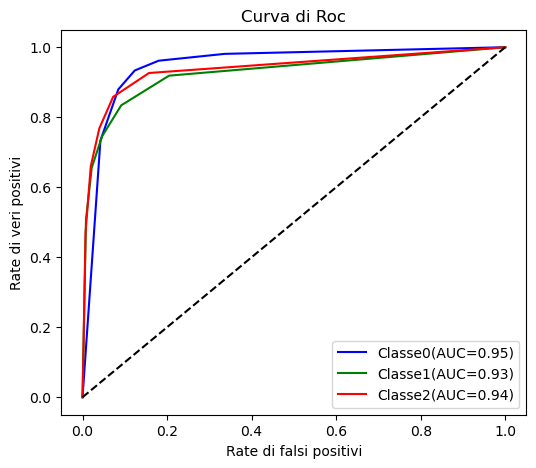

In [13]:
# Le classi sono sempre "numeriche". l'idea è una curva uno vs gli altri due.
# Ricordo le classi: 0 è la Galassia, 1 stella e 2 quasar.
classi=[0,1,2]
y_test_bin=label_binarize(taNuovo_test,classes=classi)
# Calcolo le probabilità.
yProb=model.predict_proba(feNuovo_test)  
# Calcolo il rate dei falsi positivi (FP), quello dei veri positivi (VP) e area sotto la curva (AUC) per ogni classe.
FP=dict()
VP=dict()
roc_auc=dict()
for i in range(len(classi)):
    FP[i],VP[i],_=roc_curve(y_test_bin[:, i],yProb[:, i])
    roc_auc[i] = auc(FP[i],VP[i])
# Plotto tutto.
plt.figure(figsize=(6,5))
colors=['blue','green','red']
for i,color in zip(range(len(classi)), colors):
    plt.plot(FP[i],VP[i],color=color,label=f'Classe{classi[i]}(AUC={roc_auc[i]:.2f})')
# Plotto anche la diaginale casuale, così si vede bene che i dati sono "lontani" dalla casualità.
plt.plot([0,1],[0,1],'k--')  
plt.title("Curva di Roc")
plt.xlabel("Rate di falsi positivi")
plt.ylabel("Rate di veri positivi")
plt.legend()
plt.show()

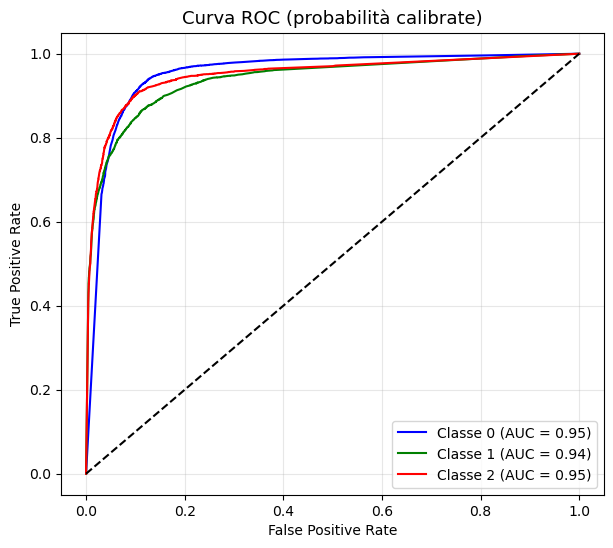

In [15]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# CLASSI
classi = [0, 1, 2]

# 1. BINARIZZAZIONE DELLE CLASSI
y_test_bin = label_binarize(taNuovo_test, classes=classi)

# 2. CALIBRAZIONE DELLE PROBABILITÀ
#    (Calibrazione tipo Platt / sigmoid, consigliata per RF)
model_cal = CalibratedClassifierCV(model, method="sigmoid", cv=5)
model_cal.fit(feNuovo_train, taNuovo_train)

# 3. PROBABILITÀ CALIBRATE
yProb = model_cal.predict_proba(feNuovo_test)

# 4. CALCOLO ROC + AUC PER OGNI CLASSE
FP = dict()
VP = dict()
roc_auc = dict()

for i in range(len(classi)):
    FP[i], VP[i], _ = roc_curve(y_test_bin[:, i], yProb_cal[:, i])
    roc_auc[i] = auc(FP[i], VP[i])

# 5. PLOT DELLE CURVE
plt.figure(figsize=(7,6))
colors = ['blue', 'green', 'red']

for i, color in zip(range(len(classi)), colors):
    plt.plot(FP[i], VP[i], color=color,
             label=f'Classe {classi[i]} (AUC = {roc_auc[i]:.2f})')

# Diagonale casuale
plt.plot([0,1], [0,1], 'k--')

plt.title("Curva ROC (probabilità calibrate)", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


##### Vedo che l'algoritmo funziona bene perchè (singolarmente) distingue bene un "oggetto" dagli altri deu. 
##### Infatti tutte le aree sono molto vicine all'1 (100% precisione).

#### Per vedere ancora meglio quanto funziona bene l'algoritmo, implemento la la cross validation k-fold con k=5

In [ ]:
# Modello sempre del random forest.
model=RandomForestClassifier(n_estimators=100,random_state=26)
# k-fold cross validation.
scores=cross_val_score(model,feNuovo,taNuovo,cv=5,scoring='accuracy')
# Printo i risultati.
print("Accuratezze nei 5 fold:",scores)
print("Accuratezza media:",np.mean(scores))
print("Deviazione standard:",np.std(scores))

##### Questo dimostra che l'algoritmo è abbastanza stabile oltre che preciso.

#### Ora che sono abbastanza certo della buona accuratezza del codice e della sua stabilità, guardo la curva di apprendimetno.
#### In questo modo caspisco meglio se i dati sono abbastanza e se sono divisi bene tra test e allenamento.

In [ ]:
# Guardo la curva di apprendimento, come modello uso sempre il random forest.
model=RandomForestClassifier(n_estimators=100, random_state=26)
train_sizes,train_scores,test_scores=learning_curve(model,feNuovo,taNuovo,cv=5,train_sizes=np.linspace(0.1,1.0,5),scoring='accuracy',n_jobs=-1)
# Calcolo media e deviazione standard.
train_mean=np.mean(train_scores,axis=1)
train_std=np.std(train_scores,axis=1)
test_mean=np.mean(test_scores,axis=1)
test_std=np.std(test_scores,axis=1)
# Plotto la curva.
plt.figure(figsize=(6,5))
plt.plot(train_sizes,train_mean,'o-',color='blue',label='Train')
plt.plot(train_sizes,test_mean,'o-',color='green',label='Test')
plt.fill_between(train_sizes,train_mean-train_std,train_mean+train_std,alpha=0.1,color='blue')
plt.fill_between(train_sizes,test_mean-test_std,test_mean+test_std,alpha=0.1,color='green')
plt.title("Curva di apprendimento")
plt.xlabel("Numero dat per training")
plt.ylabel("Accuratezza")
plt.legend()
plt.show()

##### Di sicuro il modello overfitta un po' perchè si vede la "distanza" tra le due curve (circa 0.89 contro 1), però in generale
##### l'algoritmo funziona bene perchè l'acuratezza rimane alta. In più la zona di "alone" è molto stretta attorno alla curva verde
##### questo significa che il modello è abbastanza solido e non è troppo sensibilie.

# Rete neurale

Accuratezza: 0.881

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     11909
           1       0.83      0.77      0.80      4371
           2       0.81      0.80      0.80      3720

    accuracy                           0.88     20000
   macro avg       0.85      0.84      0.85     20000
weighted avg       0.88      0.88      0.88     20000



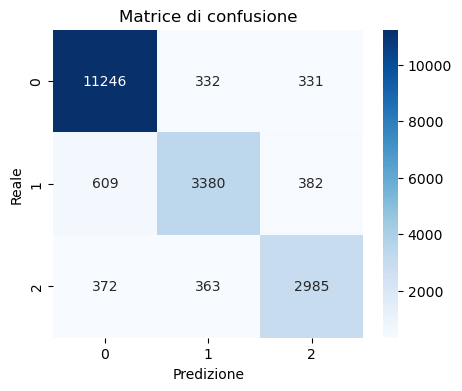

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Divido i dati (uso le stesse feature usate per Random Forest)
X_train, X_test, y_train, y_test = train_test_split(feNuovo, taNuovo, test_size=0.2, random_state=26)

# Imposto la rete neurale:
# metto due strati nascosti (100, 50 neuroni)
# come attivazione uso ReLU
# come ottimizzazione Adam
# faccio 500 iterazioni
mlp = MLPClassifier(hidden_layer_sizes=(100, 50),
                    activation='relu',
                    solver='adam',
                    max_iter=500,
                    random_state=26)

# Addestramento
mlp.fit(X_train, y_train)

# Predizione
y_pred_mlp = mlp.predict(X_test)

# Accuratezza
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuratezza: {acc_mlp:.3f}")

# Report dettagliato
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

# Matrice di confusione
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di confusione')
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.show()
